## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
YEAR = 2023
MONTH = 'July'
PERIOD = '2nd'

In [5]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_2008-2019.csv', encoding=enc)

In [6]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-07-16,2023,7,2023-07-12,45.358184,11.797125,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,2023-07-07,45.358184,11.797125,15349.0,14663.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-07-15,45.350207,11.750054,365.508363,2023-07-09,2023-07-02,2023-07-09,2023-07-02,6.413500,34.178536
1,adria,veneto,12.03247,45.07647,2023-07-16,2023,7,2023-07-12,45.075215,12.030687,0.354124,0.065375,-0.374427,-0.065375,0.417833,0.117365,-0.407913,-0.117365,0.084402,0.094864,0.054051,0.094864,2023-07-07,45.075215,12.030687,15177.0,14545.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-07-15,45.050206,12.050055,614.292642,2023-07-09,2023-07-02,2023-07-09,2023-07-02,7.656067,40.872501
2,adria,veneto,12.05787,45.05851,2023-07-16,2023,7,2023-07-12,45.057249,12.057637,0.198639,-0.042642,-0.221333,0.042642,0.266976,0.000836,-0.273315,-0.000836,0.066890,0.050795,0.051250,0.050795,2023-07-07,45.057249,12.057637,15258.0,14576.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-07-15,45.050206,12.050055,614.292642,2023-07-09,2023-07-02,2023-07-09,2023-07-02,7.656067,40.872501
3,adria,veneto,12.05787,45.07647,2023-07-16,2023,7,2023-07-12,45.075215,12.057637,0.328839,0.027236,-0.342857,-0.027236,0.409854,0.101623,-0.396952,-0.101623,0.092418,0.096543,0.061782,0.096543,2023-07-07,45.075215,12.057637,15195.0,14529.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-07-15,45.050206,12.050055,614.292642,2023-07-09,2023-07-02,2023-07-09,2023-07-02,7.656067,40.872501
4,affi,veneto,10.77673,45.55680,2023-07-16,2023,7,2023-07-12,45.555814,10.777538,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,2023-07-07,45.555814,10.777538,15087.0,14557.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-07-15,45.550208,10.750049,234.700794,2023-07-09,2023-07-02,2023-07-09,2023-07-02,6.402151,74.657804


In [7]:
# wnv_file.head()

In [8]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [11]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-07-16,2023,7,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536
1,adria,veneto,12.03247,45.07647,2023-07-16,2023,7,0.354124,0.065375,-0.374427,-0.065375,0.417833,0.117365,-0.407913,-0.117365,0.084402,0.094864,0.054051,0.094864,15177.0,14545.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,614.292642,7.656067,40.872501
2,adria,veneto,12.05787,45.05851,2023-07-16,2023,7,0.198639,-0.042642,-0.221333,0.042642,0.266976,0.000836,-0.273315,-0.000836,0.066890,0.050795,0.051250,0.050795,15258.0,14576.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,614.292642,7.656067,40.872501
3,adria,veneto,12.05787,45.07647,2023-07-16,2023,7,0.328839,0.027236,-0.342857,-0.027236,0.409854,0.101623,-0.396952,-0.101623,0.092418,0.096543,0.061782,0.096543,15195.0,14529.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,614.292642,7.656067,40.872501
4,affi,veneto,10.77673,45.55680,2023-07-16,2023,7,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804


In [12]:
# wnv_file.head(5)

In [13]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [14]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('barbarano vicentino','barbarano mossano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('biancade','roncade'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'brescia')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('castelnuovo bariano','castelnovo bariano'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('frassinelle','frassinelle polesine'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('giacciano in barucchella','giacciano con baruchella'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('godega saint urbano','godega da saint urbano'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'localita ca barzoni')].index , inplace=True)
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'mantova')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('marghera','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera','masera da padova'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('mestre','venezia'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monastier','monastier da treviso'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('monteforte','monteforte da alpone'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('montegrotto','montegrotto terme'))
# wnv_file.drop(wnv_file[(wnv_file['lau1'] == 'palermo')].index , inplace=True)
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('pra maggiore','pramaggiore'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint elena da silea','saint elena'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietri viminario','saint pietro viminario'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro morubio','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubi','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vialeggio sul mincio','valeggio sul mincio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('vo euganeo','vo'))


In [15]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [16]:
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('saint pietro da morubioo','saint pietro da morubio'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('selvazzano dentro dentro','selvazzano dentro'))
# wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('masera da padovada sul piave','masera da padova'))

In [17]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_timeline = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_timeline:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [18]:
#merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [19]:
# merged

In [20]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [21]:
merged['case'].value_counts()

0    804
Name: case, dtype: int64

In [22]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [23]:
dataset = grouped.mean()

In [24]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-07-16,abano terme,veneto,11.795390,45.357830,2023.0,7.0,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536,0.0
1,2023-07-16,adria,veneto,12.049403,45.070483,2023.0,7.0,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,15210.0,14550.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,614.292642,7.656067,40.872501,0.0
2,2023-07-16,affi,veneto,10.776730,45.556800,2023.0,7.0,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804,0.0
3,2023-07-16,agna,veneto,11.965390,45.175310,2023.0,7.0,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,15213.0,14569.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,599.293707,7.009414,22.983486,0.0
4,2023-07-16,agordo,veneto,12.059120,46.313990,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-07-16,zevio,veneto,11.127335,45.353970,2023.0,7.0,0.422196,0.094430,-0.377826,-0.094430,0.458362,0.172400,-0.403601,-0.172400,0.054944,0.058881,0.042940,0.058881,15169.5,14623.5,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,283.742224,6.280569,31.074402,0.0
567,2023-07-16,zimella,veneto,11.358050,45.347770,2023.0,7.0,0.682290,0.384645,-0.588056,-0.384645,0.602264,0.296295,-0.539806,-0.296295,0.094027,0.110762,0.058663,0.110762,15201.0,14555.0,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,274.319462,6.081703,34.237711,0.0
568,2023-07-16,zoppe da cadore,veneto,12.178780,46.388350,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0
569,2023-07-16,zovencedo,veneto,11.494300,45.437980,2023.0,7.0,0.682373,0.285089,-0.567844,-0.285089,0.672487,0.266746,-0.563673,-0.266746,0.014126,0.016971,0.012478,0.016971,14973.0,14558.0,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,253.544025,4.418517,30.723389,0.0


In [25]:
dataset = dataset.astype({'case': 'int'})

In [26]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [27]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [28]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [29]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [30]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-07-16,abano terme,veneto,11.79539,45.35783,2023,7,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536,0,16,28,46.86645,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
1,2023-07-16,adria,veneto,12.04940,45.07048,2023,7,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,15210.0,14550.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,614.292642,7.656067,40.872501,0,16,28,46.65336,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
2,2023-07-16,affi,veneto,10.77673,45.55680,2023,7,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804,0,16,28,46.81410,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
3,2023-07-16,agna,veneto,11.96539,45.17531,2023,7,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,15213.0,14569.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,599.293707,7.009414,22.983486,0,16,28,46.73306,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
4,2023-07-16,agordo,veneto,12.05912,46.31399,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,28,47.85821,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-07-16,zevio,veneto,11.12733,45.35397,2023,7,0.422196,0.094430,-0.377826,-0.094430,0.458362,0.172400,-0.403601,-0.172400,0.054944,0.058881,0.042940,0.058881,15169.5,14623.5,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,283.742224,6.280569,31.074402,0,16,28,46.69904,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
567,2023-07-16,zimella,veneto,11.35805,45.34777,2023,7,0.682290,0.384645,-0.588056,-0.384645,0.602264,0.296295,-0.539806,-0.296295,0.094027,0.110762,0.058663,0.110762,15201.0,14555.0,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,274.319462,6.081703,34.237711,0,16,28,46.74854,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
568,2023-07-16,zoppe da cadore,veneto,12.17878,46.38835,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,28,47.96042,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231
569,2023-07-16,zovencedo,veneto,11.49430,45.43798,2023,7,0.682373,0.285089,-0.567844,-0.285089,0.672487,0.266746,-0.563673,-0.266746,0.014126,0.016971,0.012478,0.016971,14973.0,14558.0,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,253.544025,4.418517,30.723389,0,16,28,46.86928,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231


<AxesSubplot:>

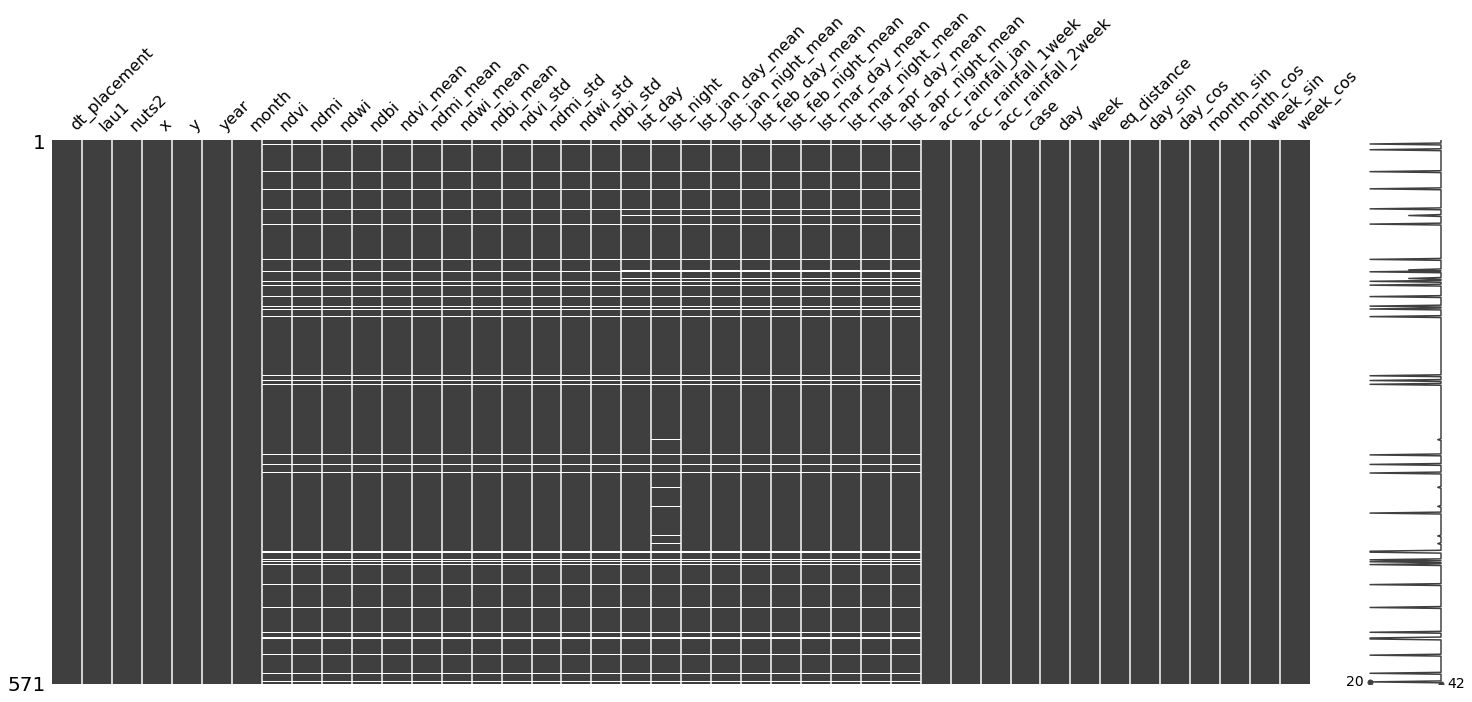

In [31]:
missingno.matrix(dataset)

In [32]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [33]:
df_demographics

,lau1,nuts3,nuts2,population
0,abano terme,padova,veneto,"19,349"
1,adria,rovigo,veneto,"20,233"
2,affi,verona,veneto,"2,297"
3,agna,padova,veneto,"3,400"
4,agordo,belluno,veneto,"4,249"
...,...,...,...,...
576,zimella,verona,veneto,"4,834"
577,zoldo alto,belluno,veneto,999
578,zoppe da cadore,belluno,veneto,265
579,zovencedo,vicenza,veneto,796


In [34]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_LOWER}'").copy()

In [35]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [36]:
df_demographics_nuts2

,lau1,population
0,abano terme,"19,349"
1,adria,"20,233"
2,affi,"2,297"
3,agna,"3,400"
4,agordo,"4,249"
...,...,...
576,zimella,"4,834"
577,zoldo alto,999
578,zoppe da cadore,265
579,zovencedo,796


In [37]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['alpago', 'barbarano mossano', 'borgo veneto', 'brenzone sul garda', 'costermano sul garda', 'quero vas', 'val da zoldo', 'val liona']

Length: 8


In [38]:
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'alpago', 'population':6858}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('mossano','barbarano mossano'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'borgo veneto', 'population':7000}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'brenzone sul garda', 'population':2452}, ignore_index=True)
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('costermano','costermano sul garda'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('quero','quero vas'))
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val da zoldo', 'population':3242}, ignore_index=True)
df_demographics_nuts2 = df_demographics_nuts2.append({'lau1':'val liona', 'population':3047}, ignore_index=True)


In [39]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [40]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

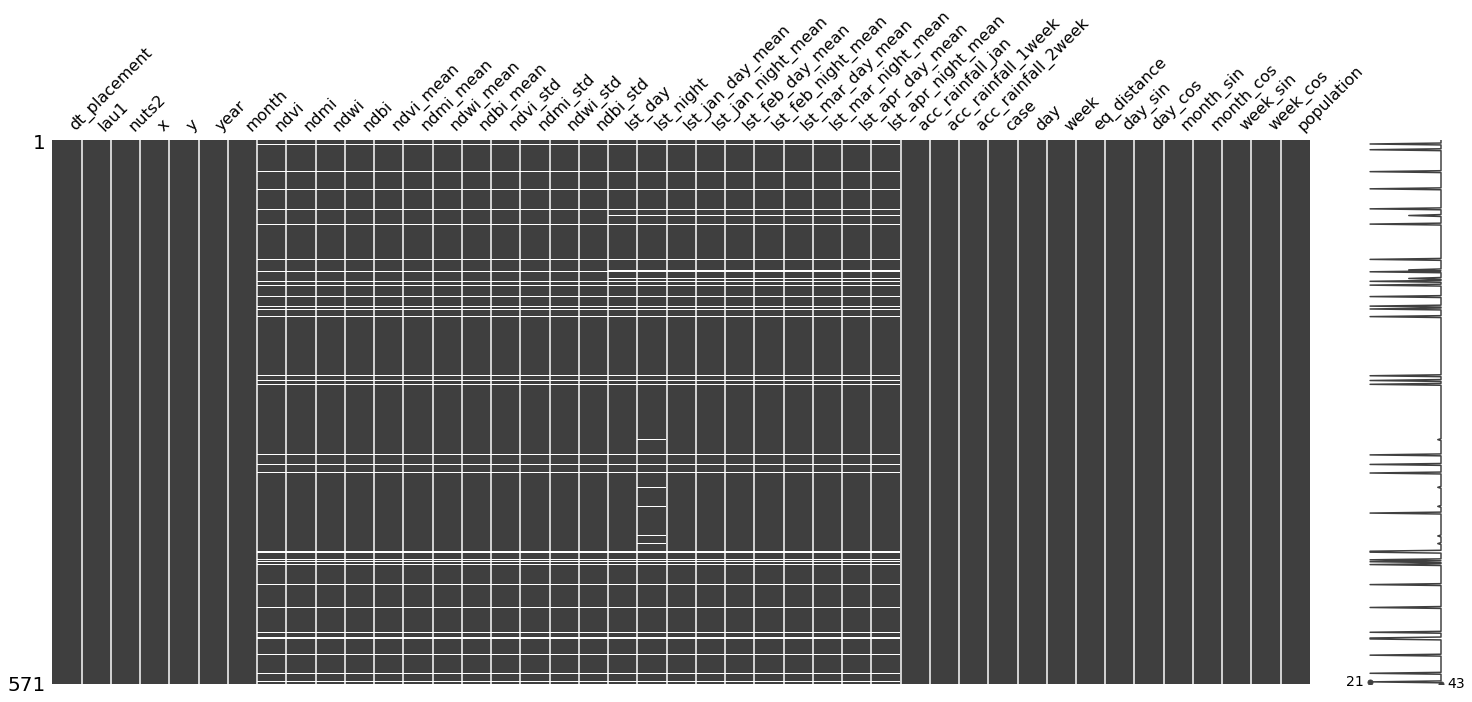

In [41]:
missingno.matrix(dataset)

In [42]:
missing = describe_dataframe(dataset)

In [43]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population
0,2023-07-16,abano terme,veneto,11.79539,45.35783,2023,7,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536,0,16,28,46.86645,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"19,349"
1,2023-07-16,adria,veneto,12.04940,45.07048,2023,7,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,15210.0,14550.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,614.292642,7.656067,40.872501,0,16,28,46.65336,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"20,233"
2,2023-07-16,affi,veneto,10.77673,45.55680,2023,7,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804,0,16,28,46.81410,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"2,297"
3,2023-07-16,agna,veneto,11.96539,45.17531,2023,7,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,15213.0,14569.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,599.293707,7.009414,22.983486,0,16,28,46.73306,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"3,400"
4,2023-07-16,agordo,veneto,12.05912,46.31399,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,28,47.85821,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,249"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-07-16,zevio,veneto,11.12733,45.35397,2023,7,0.422196,0.094430,-0.377826,-0.094430,0.458362,0.172400,-0.403601,-0.172400,0.054944,0.058881,0.042940,0.058881,15169.5,14623.5,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,283.742224,6.280569,31.074402,0,16,28,46.69904,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"14,413"
567,2023-07-16,zimella,veneto,11.35805,45.34777,2023,7,0.682290,0.384645,-0.588056,-0.384645,0.602264,0.296295,-0.539806,-0.296295,0.094027,0.110762,0.058663,0.110762,15201.0,14555.0,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,274.319462,6.081703,34.237711,0,16,28,46.74854,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,834"
568,2023-07-16,zoppe da cadore,veneto,12.17878,46.38835,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,28,47.96042,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,265
569,2023-07-16,zovencedo,veneto,11.49430,45.43798,2023,7,0.682373,0.285089,-0.567844,-0.285089,0.672487,0.266746,-0.563673,-0.266746,0.014126,0.016971,0.012478,0.016971,14973.0,14558.0,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,253.544025,4.418517,30.723389,0,16,28,46.86928,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,796


In [44]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-07-16,54
1,12.049403,45.070483,2023-07-16,161
2,10.776730,45.556800,2023-07-16,29
3,11.965390,45.175310,2023-07-16,146
4,12.059120,46.313990,2023-07-16,20
...,...,...,...,...
566,11.127335,45.353970,2023-07-16,166
567,11.358050,45.347770,2023-07-16,329
568,12.178780,46.388350,2023-07-16,19
569,11.494300,45.437980,2023-07-16,198


In [45]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [46]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [47]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0011119492665983


In [48]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [49]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [50]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [51]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,mosq_pred
0,2023-07-16,abano terme,veneto,11.79539,45.35783,2023,7,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536,0,16,28,46.86645,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"19,349",54
1,2023-07-16,adria,veneto,12.04940,45.07048,2023,7,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,15210.0,14550.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,614.292642,7.656067,40.872501,0,16,28,46.65336,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"20,233",161
2,2023-07-16,affi,veneto,10.77673,45.55680,2023,7,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804,0,16,28,46.81410,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"2,297",29
3,2023-07-16,agna,veneto,11.96539,45.17531,2023,7,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,15213.0,14569.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,599.293707,7.009414,22.983486,0,16,28,46.73306,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"3,400",146
4,2023-07-16,agordo,veneto,12.05912,46.31399,2023,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0,16,28,47.85821,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,249",20


<AxesSubplot:>

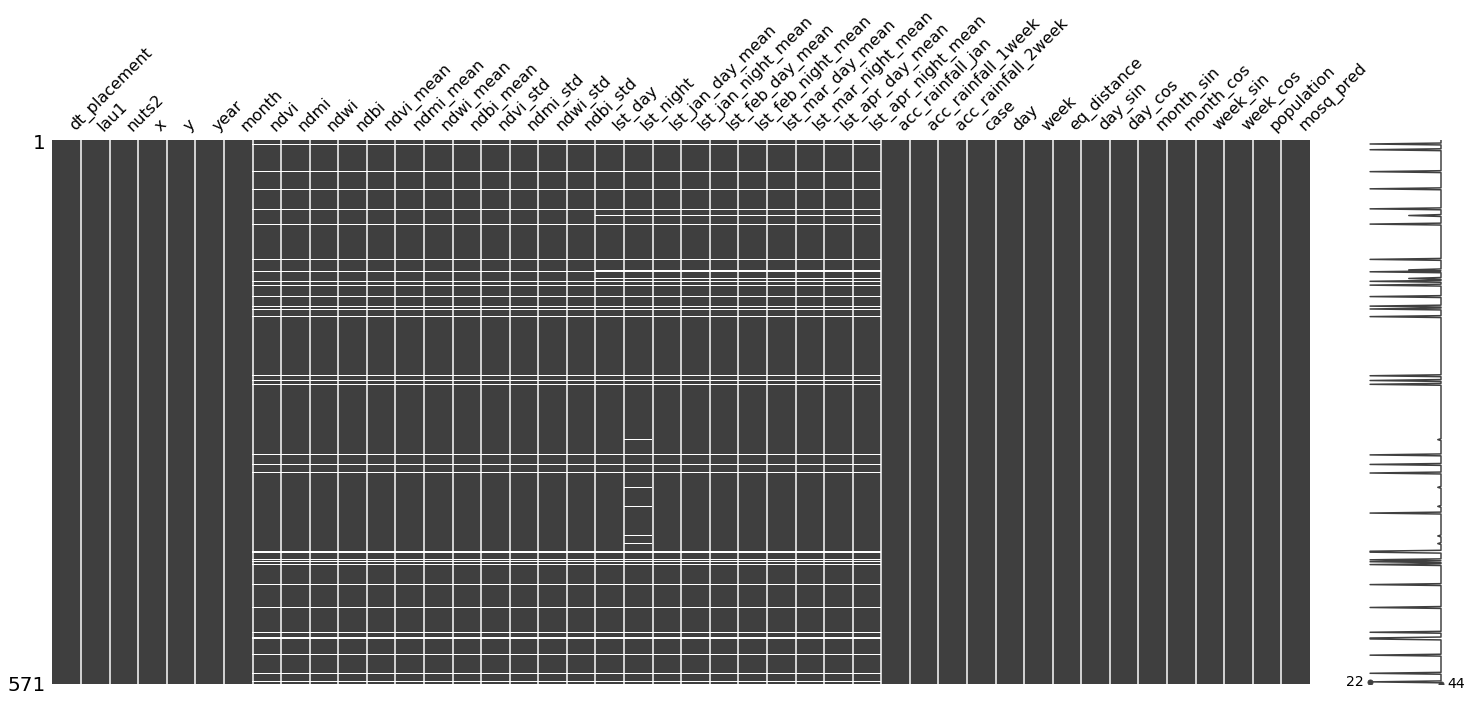

In [52]:
missingno.matrix(dataset)

In [53]:
dataset.reset_index(inplace=True, drop=True)

In [54]:
dataset = calculate_mosq_previous(dataset)

In [55]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

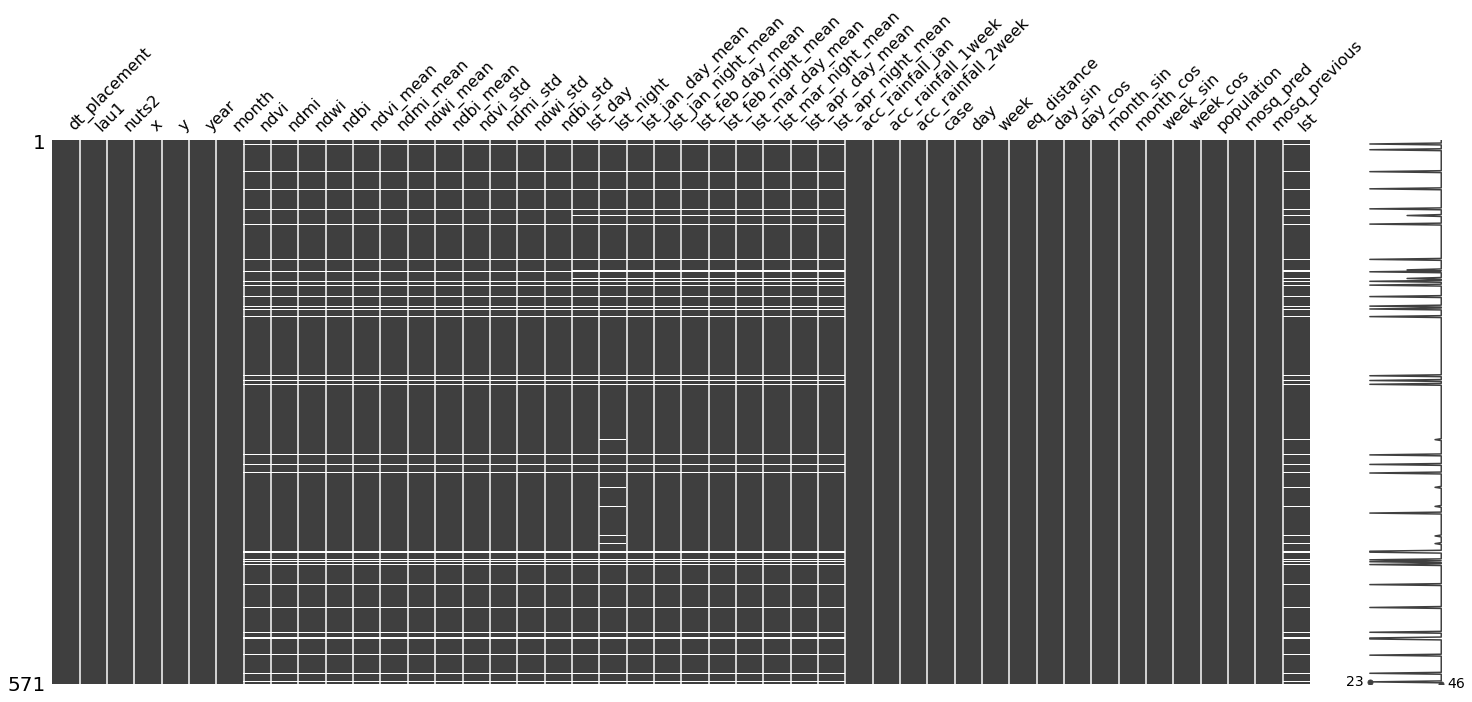

In [56]:
missingno.matrix(dataset)

In [57]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [58]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [59]:
dataset = convert_multiple_cases(dataset)

In [60]:
dataset['case'].value_counts()

0    571
Name: case, dtype: int64

In [61]:
cols = dataset.columns

In [62]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'population', 'mosq_pred',
       'mosq_previous', 'lst'],
      dtype='object')

In [63]:
len(cols)

46

In [64]:
# check columns

In [65]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'population',
                 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [66]:
len(final_columns)

46

In [67]:
dataset_final = dataset[final_columns].copy()

In [68]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,11.79539,45.35783,2023-07-16,veneto,abano terme,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"19,349",46.86645,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,26.97,33.83,20.11,7.577500,0.803333,8.080000,-0.791538,18.345385,6.490000,21.500769,6.950000,6.413500,34.178536,365.508363,54,0,0
1,12.04940,45.07048,2023-07-16,veneto,adria,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"20,233",46.65336,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,24.45,31.05,17.85,6.080278,1.536222,8.109212,-1.341825,16.869545,4.825897,21.349744,5.723333,7.656067,40.872501,614.292642,161,0,0
2,10.77673,45.55680,2023-07-16,veneto,affi,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"2,297",46.81410,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,23.29,28.59,17.99,6.294444,0.807143,8.631538,0.720667,17.180000,4.251429,18.359412,6.878889,6.402151,74.657804,234.700794,29,0,0
3,11.96539,45.17531,2023-07-16,veneto,agna,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"3,400",46.73306,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,24.67,31.11,18.23,4.340000,0.585000,7.752222,-2.034615,15.996667,4.427778,21.254615,5.119231,7.009414,22.983486,599.293707,146,0,0
4,12.05912,46.31399,2023-07-16,veneto,agordo,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,249",47.85821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,11.12733,45.35397,2023-07-16,veneto,zevio,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"14,413",46.69904,0.422196,0.094430,-0.377826,-0.094430,0.458362,0.172400,-0.403601,-0.172400,0.054944,0.058881,0.042940,0.058881,24.78,30.24,19.32,6.378889,-0.917321,8.835500,-1.520625,18.972857,4.872909,21.292167,6.713750,6.280569,31.074402,283.742224,166,0,0
567,11.35805,45.34777,2023-07-16,veneto,zimella,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,"4,834",46.74854,0.682290,0.384645,-0.588056,-0.384645,0.602264,0.296295,-0.539806,-0.296295,0.094027,0.110762,0.058663,0.110762,24.41,30.87,17.95,5.460000,0.020000,9.545000,-1.560588,19.397059,5.144000,23.106923,6.004000,6.081703,34.237711,274.319462,329,0,0
568,12.17878,46.38835,2023-07-16,veneto,zoppe da cadore,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,265,47.96042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,19,0,0
569,11.49430,45.43798,2023-07-16,veneto,zovencedo,16,7,28,2023,-0.101168,-0.994869,-0.5,-0.866025,-0.17689,-0.984231,796,46.86928,0.682373,0.285089,-0.567844,-0.285089,0.672487,0.266746,-0.563673,-0.266746,0.014126,0.016971,0.012478,0.016971,22.16,26.31,18.01,5.718333,1.404286,8.158333,1.778000,15.127500,6.664545,17.232500,6.598000,4.418517,30.723389,253.544025,198,0,0


In [69]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)